# **<u>Environment and Storage setup<u>**

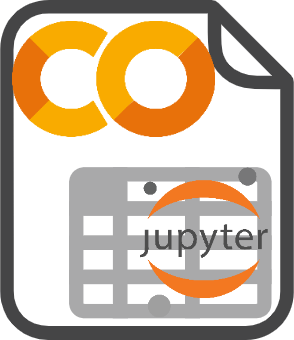

For custom HCR probe storage, you have two options:

* **Google Drive (Recommended)**:
Use this if you want your data to persist across sessions. Files saved in Google Drive will remain available even after the Colab runtime ends.

* Local Runtime (Temporary):
Data will be stored in the Colab environment only. It will be lost when the session disconnects or restarts.

**Tip**: If you plan to keep your data for future use, choose **Google Drive**.

**Notes**: If this is your **FIRST** TIME connecting to google drive. See the instructions below.

# <u>Google Drive instructions:</u>
If you choose to use **Google Drive**, please use the instructions below:



* When prompted, Click on **Connect to Google Drive**
  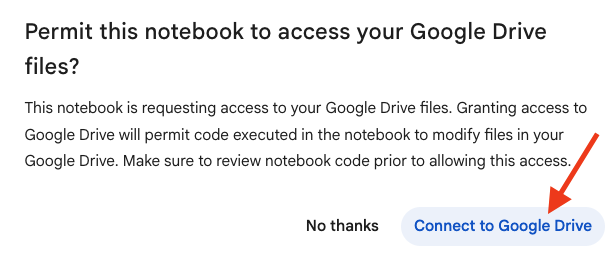
* Choose your **gmail** account
  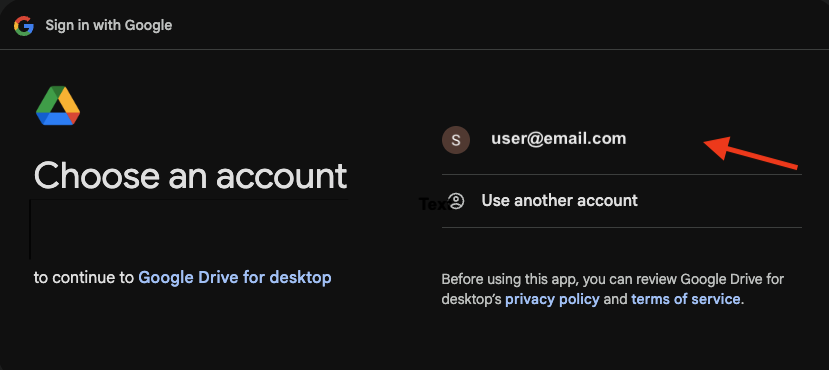
* Click on **Continue** when prompted for permissions
  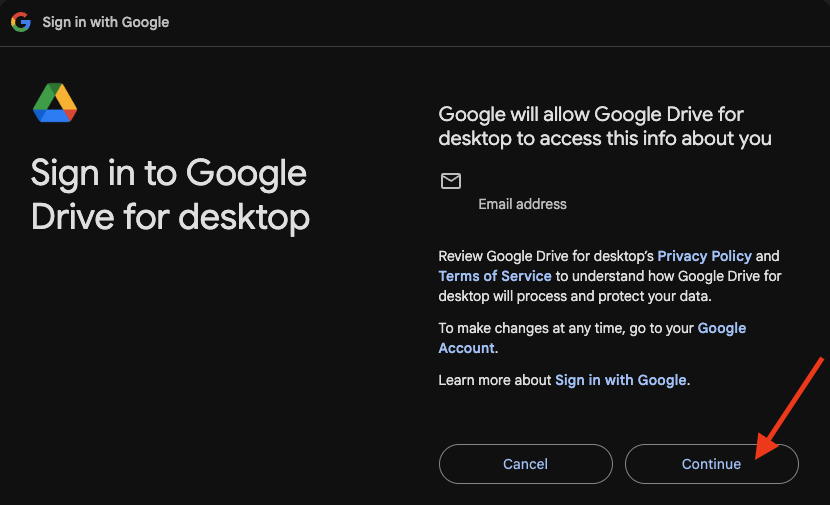
* When it asks for which permissions, match the screenshot below and click on **Continue**  
  if you have previously given permissions, then just click on **Continue**  
  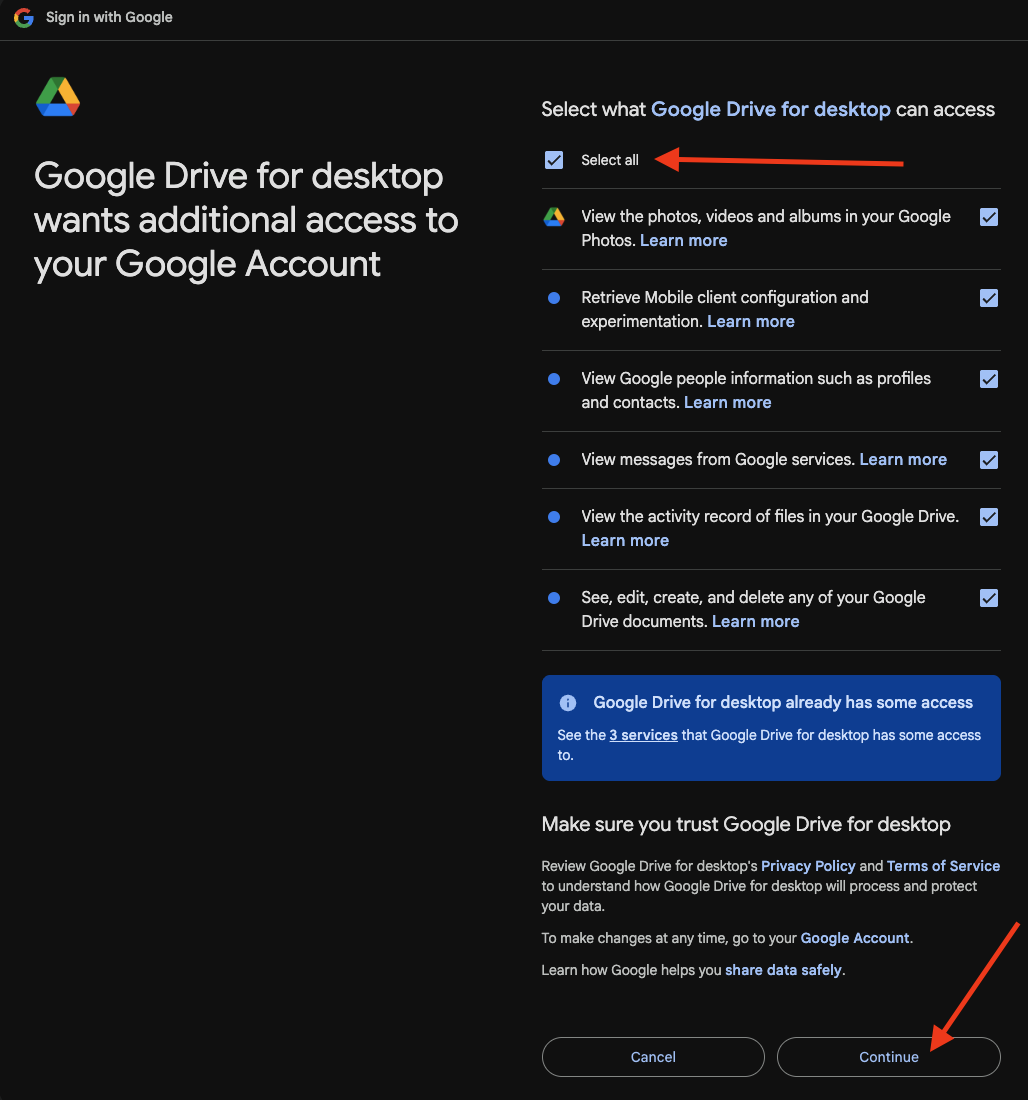


# **I. STORAGE SELECTION**

In [ ]:
# @title Click 𝗥𝗨𝗡 to choose a storage option 🔵:
from pathlib import Path
import os
from IPython.display import display, Markdown
import ipywidgets as widgets

# ------- Config you can customize -------
DRIVE_MOUNT_POINT = "/content/drive"
DEFAULT_LOCAL_DIR = Path("/content/HCR-probe")
DEFAULT_DRIVE_DIR = Path(DRIVE_MOUNT_POINT) / "MyDrive" / "HCR-probe"
ENV_KEY = "BASE_DIR"
ENV_STORAGE_TYPE = "STORAGE_TYPE"
# ---------------------------------------

def ensure_dir(p: Path) -> Path:
    p.mkdir(parents=True, exist_ok=True)
    return p

def drive_is_mounted() -> bool:
    # In Colab, Drive is considered mounted if both mount point and MyDrive exist
    return os.path.isdir(DRIVE_MOUNT_POINT) and os.path.isdir(os.path.join(DRIVE_MOUNT_POINT, "MyDrive"))

# If already configured, show and exit (idempotent on re-runs)
if ENV_KEY in os.environ and os.path.isdir(os.environ[ENV_KEY]):
    display(Markdown(f"Using **{ENV_KEY}**: `{os.environ[ENV_KEY]}` ✅"))
    display(Markdown(f"Using **{ENV_STORAGE_TYPE}**: `{os.environ[ENV_STORAGE_TYPE]} ✅`"))
else:
    # Build UI
    choice = widgets.RadioButtons(
        options=[
            ("Google Drive (persistent)", "drive"),
            ("Local runtime /content (temporary)", "local"),
        ],
        value="drive",
        description="Store to:",
        style={"description_width": "initial"},
    )

    confirm = widgets.Button(description="Use this location", button_style="primary")
    out = widgets.Output()

    def on_confirm(_):
        with out:
            out.clear_output()
            target_dir = None
            target_storage_type = ''

            if choice.value == "drive":
                if not drive_is_mounted():
                    # Mount only if not already mounted
                    try:
                        from google.colab import drive  # type: ignore
                        drive.mount(DRIVE_MOUNT_POINT, force_remount=True)
                    except Exception as e:
                        print("⚠️ Could not mount Google Drive; falling back to local /content.")
                        print(e)
                        target_dir = ensure_dir(DEFAULT_LOCAL_DIR)
                # If mount succeeded or was already mounted
                if target_dir is None:
                    target_dir = ensure_dir(DEFAULT_DRIVE_DIR)
                target_storage_type = "GoogleDrive"
            else:
                target_dir = ensure_dir(DEFAULT_LOCAL_DIR)
                target_storage_type = "LocalStorage"

            os.environ[ENV_KEY] = str(target_dir)
            os.environ[ENV_STORAGE_TYPE] = target_storage_type
            print(f"Using {ENV_KEY} = {os.environ[ENV_KEY]}✅ ")
            print(f"Using {ENV_STORAGE_TYPE} = {os.environ[ENV_STORAGE_TYPE]}✅ ")
            display(Markdown(f"**Folder:** `{os.environ[ENV_KEY]}`"))

            # Disable UI after selection to avoid re-triggering
            choice.disabled = True
            confirm.disabled = True

    # Avoid stacking multiple handlers if the cell is re-run
    try:
        confirm.on_click(on_confirm, remove=True)  # remove if previously registered
    except Exception:
        pass
    confirm.on_click(on_confirm)

    display(choice, confirm, out)


In [ ]:
# @title Click 𝗥𝗨𝗡 and 𝗪𝗔𝗜𝗧… ⏳ until storage is selected ✅:
# ⛔ Do not run this cell until you've clicked the button above!
import os

if ENV_KEY not in os.environ:
    print("❌ BASE_DIR is not set. Please run the previous cell and click the button.")
    raise RuntimeError("ERROR. SEE ABOVE MESSAGE")
else:
    print(f"✅ BASE_DIR is set to: {os.environ[ENV_KEY]}")



# **II. SETUP**

In [ ]:
# @title Click 𝗥𝗨𝗡 to setup Global variables ☁️:
import os
#BASE_DIR
BASE_DIR = os.environ["BASE_DIR"]

#SYSTEM
ARCH = "x64-linux"  # still used for the archive filename

#BLAST
BLAST_VERSION = "2.17.0"
BLAST_TAR_NAME = f"ncbi-blast-{BLAST_VERSION}+-{ARCH}.tar.gz"
BLAST_URL = f"https://ftp.ncbi.nlm.nih.gov/blast/executables/blast+/{BLAST_VERSION}/{BLAST_TAR_NAME}"
# IMPORTANT: extracted folder usually does NOT include "-x64-linux"
BLAST_DIR = f"{BASE_DIR}/ncbi-blast-{BLAST_VERSION}+"
BLAST_BINARY = f"{BLAST_DIR}/bin/blastn"
TMP_BLAST_DIR = f"/tmp/ncbi-blast-{BLAST_VERSION}+"
TMP_BLAST_BINARY = f"{TMP_BLAST_DIR}/bin/blastn"
os.environ["PATH"] = f"{BLAST_DIR}/bin:{os.environ['PATH']}"
os.environ["BLAST_BINARY"] = BLAST_BINARY
os.environ["TMP_BLAST_DIR"] = TMP_BLAST_DIR
os.environ["TMP_BLAST_BINARY"] = TMP_BLAST_BINARY
os.environ["BLAST_DIR"] = BLAST_DIR
os.environ["BLAST_VERSION"] = BLAST_VERSION
os.environ["BLAST_TAR_NAME"] = BLAST_TAR_NAME
os.environ["BLAST_URL"] = BLAST_URL

#REPO
PROBE_GIT_URL="https://github.com/DelRioTsonisLab/HCR-probes-Tool.git"
PROBE_GIT_BRANCH="main"
PROBE_REPO_PARENT=f"{BASE_DIR}/code"
PROBE_REPO_NAME="insitu"
PROBE_REPO_DIR=f"{PROBE_REPO_PARENT}/{PROBE_REPO_NAME}"

print("Sucessfully setup global variables...✅")

In [ ]:
# @title Click 𝗥𝗨𝗡 to download Blast 📁:
%%bash
set -euo pipefail
# Check if blastn is already installed
echo "$BLAST_BINARY"
if [ ! -f "$BLAST_BINARY" ]; then
    echo "blastn not found. Downloading BLAST+..."

    # Create temp directory
    mkdir -p /tmp

    # Download and extract
    cd /tmp
    wget -q "$BLAST_URL"
    tar -xzf "$BLAST_TAR_NAME"
    rm "$BLAST_TAR_NAME"

    # Make binaries executable
    chmod +x "${TMP_BLAST_DIR}/bin/"*

    # Copy blastn to target location
    mkdir -p "$(dirname "$BLAST_BINARY")"
    cp "${TMP_BLAST_DIR}/bin/"* "$(dirname "$BLAST_BINARY")"
else
    echo "blastn is already installed."
fi

chmod +x "${BLAST_BINARY}"
# Add to PATH
export PATH="${BLAST_DIR}/bin:$PATH"

# Verify installation
"$BLAST_BINARY" -version


echo "Sucessfully setup blastn binary...✅"

In [ ]:
# @title Click 𝗥𝗨𝗡 to set GIT REPO env variables ☁️:

os.environ["PROBE_GIT_URL"] = PROBE_GIT_URL
os.environ["PROBE_REPO_DIR"] = PROBE_REPO_DIR
os.environ["PROBE_REPO_NAME"] = PROBE_REPO_NAME
os.environ["PROBE_REPO_PARENT"] = PROBE_REPO_PARENT
os.environ["PROBE_GIT_BRANCH"] = PROBE_GIT_BRANCH
print("Sucessfully set GIT variables for the probe...✅")

In [ ]:
# @title Click 𝗥𝗨𝗡 to download HCR Codebase 📁:
%%bash
set -euo pipefail

mkdir -p ${PROBE_REPO_DIR}
if [ -d "$PROBE_REPO_DIR/.git" ]; then
  echo "[info] Repo exists. Pulling latest..."
  echo here
  git -C "$PROBE_REPO_DIR" fetch --all --prune
  git -C "$PROBE_REPO_DIR" checkout "$PROBE_GIT_BRANCH"
  git -C "$PROBE_REPO_DIR" pull
else
  echo "[info] Cloning fresh copy..."
  cd "$PROBE_REPO_PARENT"
  git clone -b "$PROBE_GIT_BRANCH" "$PROBE_GIT_URL" "$PROBE_REPO_NAME"
fi

echo "Sucessfully set and updated the codebase...✅"


In [ ]:
# @title Click 𝗥𝗨𝗡 to create python cache for requirements ☁️:
import os

# Define cache directory inside Google Drive
pip_cache_dir = f"{BASE_DIR}/pip_cache"
os.makedirs(pip_cache_dir, exist_ok=True)
os.environ["pip_cache_dir"]=pip_cache_dir

print("Created pip cache directory...✅")


In [ ]:
# @title Click 𝗥𝗨𝗡 to install the python packages and dependencies 📁:
%%bash
set -euo pipefail

if [[ -f "${PROBE_REPO_DIR}/packages.txt" ]]; then
  echo "Installing packages from repository..."
  pip -q install -r "${PROBE_REPO_DIR}/packages.txt" --cache-dir=${pip_cache_dir}
else
  echo "Using Fallback packages list..."
  pip -q install \
  ipyfilechooser==0.6.0 \
  biopython==1.85 \
  pandas==2.2.2 \
  matplotlib==3.10.0 \
  numpy==2.0.2 \
  scipy==1.16.1 \
  future==1.0.0 \
  emoji==2.14.1 \
  openpyxl==3.1.5 \
  ipywidgets==7.7.1 \
  --cache-dir=${pip_cache_dir}
fi

echo "Sucessfully installed pip packages and dependencies...✅"


#**III. UPLOAD DATA**

In [ ]:
# @title Click 𝗥𝗨𝗡 to upload or locate FASTA file 🔎:
from pathlib import Path
import os
from IPython.display import display, Markdown
import ipywidgets as widgets

# ---------------- Config ----------------
ENV_KEY = "BASE_DIR"         # Set by your "Choose Storage Option" cell
SUBDIR = "data"              # Files will live under BASE_DIR/data/
FASTA_EXTS = {               # Recognized FASTA-like extensions
    ".fa", ".fasta", ".fna", ".fsa", ".fas",
    ".fa.gz", ".fasta.gz", ".fna.gz", ".fsa.gz", ".fas.gz"
}
# ----------------------------------------

def _ensure_dir(p: Path) -> Path:
    p.mkdir(parents=True, exist_ok=True)
    return p

def _is_fasta_like(path: Path) -> bool:
    # Handles .fa.gz style suffixes
    suffixes = "".join(path.suffixes).lower()
    if suffixes in FASTA_EXTS:
        return True
    # Also allow simple single suffix check (e.g., .fa)
    if path.suffix.lower() in {".fa", ".fasta", ".fna", ".fsa", ".fas"}:
        return True
    return False

def _list_fasta_files(dir_path: Path):
    # Search only in BASE_DIR/data (non-recursive to keep it predictable)
    if not dir_path.exists():
        return []
    return sorted([p for p in dir_path.iterdir() if p.is_file() and _is_fasta_like(p)])

def _unique_destination(dest: Path, overwrite: bool) -> Path:
    """Return a unique path if not overwriting and file exists, preserving multi-suffix like .fa.gz."""
    if overwrite or not dest.exists():
        return dest
    # Keep all suffixes intact (e.g., .fa.gz)
    base = dest.name
    stem = dest.name
    suffix = ""
    # Extract all suffixes while preserving name base
    if dest.suffixes:
        suffix = "".join(dest.suffixes)
        stem = dest.name[: -len(suffix)]
    # Add (1), (2), ... before suffix
    i = 1
    while True:
        candidate = dest.with_name(f"{stem} ({i}){suffix}")
        if not candidate.exists():
            return candidate
        i += 1

def _do_upload(data_dir: Path, overwrite_checkbox: widgets.Checkbox):
    try:
        from google.colab import files as colab_files  # type: ignore
    except Exception:
        print("⚠️ This upload widget requires Google Colab.")
        return

    display(Markdown(f"**Upload FASTA files to** `{data_dir}`"))
    uploaded = colab_files.upload()  # user picks files in the browser
    if not uploaded:
        print("No files selected.")
        return

    saved_paths = []
    for name, data in uploaded.items():
        dest = _unique_destination(data_dir / name, overwrite_checkbox.value)
        # Write the bytes returned by files.upload()
        with open(dest, "wb") as f:
            f.write(data)
        saved_paths.append(dest)
        print(f"Saved: {dest}")

    # Export convenience handles
    os.environ["DATA_DIR"] = str(data_dir)
    globals()["DATA_DIR"] = data_dir
    globals()["DATA_FILES"] = [str(p) for p in saved_paths]
    display(Markdown(f"✅ Upload complete. Files are in `{data_dir}`"))

# ===== Entry Point =====

if ENV_KEY not in os.environ or not os.path.isdir(os.environ[ENV_KEY]):
    display(Markdown("⚠️ `BASE_DIR` is not set or not a directory. "
                     "Please run the **Choose Storage Option** cell first."))
else:
    BASE_DIR = Path(os.environ[ENV_KEY])
    DATA_DIR = _ensure_dir(BASE_DIR / SUBDIR)

    display(Markdown(f"**Storage Type :** `{DATA_DIR}`"))
    display(Markdown(f"**Data folder:** `{os.environ[ENV_STORAGE_TYPE]}`"))

    # UI controls
    mode = widgets.RadioButtons(
        options=[
            ("Use existing files", "existing"),
            ("Upload FASTA file(s) now", "upload"),
        ],
        value="existing",
        description="Data source:",
        style={"description_width": "initial"},
    )
    overwrite = widgets.Checkbox(
        value=False,
        description="Overwrite existing files with same name",
        indent=False,
    )
    confirm = widgets.Button(description="Continue", button_style="primary")
    out = widgets.Output()

    def on_confirm(_):
        with out:
            out.clear_output()
            # Ensure the target directory exists
            _ensure_dir(DATA_DIR)

            if mode.value == "existing":
                existing = _list_fasta_files(DATA_DIR)
                if existing:
                    display(Markdown(f"✅ Found **{len(existing)}** FASTA-like file(s) in `{DATA_DIR}`:"))
                    for p in existing:
                        print(" -", p.name)
                    os.environ["DATA_DIR"] = str(DATA_DIR)
                    globals()["DATA_DIR"] = DATA_DIR
                    globals()["DATA_FILES"] = [str(p) for p in existing]
                    display(Markdown("You can proceed to the next step."))
                else:
                    display(Markdown(
                        f"⚠️ No FASTA-like files found in `{DATA_DIR}`.\n\n"
                        f"Please upload them now:"
                    ))
                    _do_upload(DATA_DIR, overwrite)
            else:
                _do_upload(DATA_DIR, overwrite)

            # Lock the UI to avoid multiple triggers
            mode.disabled = True
            overwrite.disabled = True
            confirm.disabled = True

    # Avoid stacking multiple handlers if the cell is re-run
    try:
        confirm.on_click(on_confirm, remove=True)
    except Exception:
        pass
    confirm.on_click(on_confirm)

    display(mode, overwrite, confirm, out)


# **IV. START THE HCR PROBE MAKER**

In [ ]:
# @title Click 𝗥𝗨𝗡 to initialize the environment ⚙️:
import sys
module_path = os.path.abspath(PROBE_REPO_DIR)
if module_path not in sys.path:
    sys.path.append(module_path)

os.chdir(f"{BASE_DIR}/data")

In [ ]:
# @title Click 𝗥𝗨𝗡 to set input parameters 📄:
from IPython.display import display, HTML
display(HTML("<style>.jp-CodeCell.jp-mod-outputsScrolled .jp-Cell-outputArea { max-height: 100em; }</style>"))
from makercb import maker
from helper import load_idt
load_idt()

In [ ]:
# @title Click 𝗥𝗨𝗡 to generate probes and export files 💾:
maker(name,fullseq,amplifier,pause,choose,polyAT,polyCG,BlastProbes,db,dropout,show,report,maxprobe,numbr)
